# House Price Dataset Analysis

This notebook is a cleaner and more complete version of the original work. It focuses mainly on:

1. loading and cleaning the dataset
2. exploratory data analysis (EDA)
3. market insights by city, property type, and location
4. engineered features such as `price_per_marla`
5. a short machine learning baseline at the end

The main goal is to understand the structure of the housing market before modeling it.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 50)

## 1. Load and clean the dataset

The raw CSV contains an extra unnamed index-like column. We remove it and convert the numeric fields into the correct types.

In [2]:
data_path = Path("house_price_dataset.csv")
df = pd.read_csv(data_path)

df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.columns = df.columns.str.strip()

numeric_cols = ["price", "baths", "bedrooms", "Area_in_Marla"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["property_type", "location", "city", "purpose"]:
    df[col] = df[col].astype("string").str.strip()

df.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


## 2. Dataset overview

We begin with shape, dtypes, missing values, duplicates, and a compact summary of the dataset.

In [3]:
overview = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "cities": df["city"].nunique(),
    "locations": df["location"].nunique(),
    "property_types": df["property_type"].nunique(),
    "purposes": df["purpose"].nunique(),
    "duplicates": int(df.duplicated().sum()),
})

display(overview.to_frame("value"))
display(df.dtypes.to_frame("dtype"))

,value
rows,99499
columns,8
cities,5
locations,1389
property_types,7
purposes,2
duplicates,37858


,dtype
property_type,string
price,int64
location,string
city,string
baths,int64
purpose,string
bedrooms,int64
Area_in_Marla,float64


In [4]:
missing = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
property_type,0,0.0
price,0,0.0
location,0,0.0
city,0,0.0
baths,0,0.0
purpose,0,0.0
bedrooms,0,0.0
Area_in_Marla,0,0.0


In [5]:
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
price,99499.0,10375919.50,10659998.26,15500.0,150000.0,7500000.0,15500000.0,44900000.0
baths,99499.0,3.53,1.47,1.0,2.0,3.0,5.0,7.0
bedrooms,99499.0,3.35,1.26,0.0,2.0,3.0,4.0,6.0
Area_in_Marla,99499.0,8.76,7.47,0.0,4.8,6.7,10.0,194.0


## 3. Feature engineering for analysis

These engineered columns help us compare homes more fairly.

- `price_million`: easier to read than raw prices
- `price_per_marla`: price normalized by area
- `bedrooms_per_marla`: rough density indicator

In [6]:
df = df.dropna(subset=["price", "Area_in_Marla"]).copy()
df = df[df["Area_in_Marla"] > 0].copy()

df["price_million"] = df["price"] / 1_000_000
df["price_per_marla"] = df["price"] / df["Area_in_Marla"]
df["bedrooms_per_marla"] = df["bedrooms"] / df["Area_in_Marla"]
df["log_price"] = np.log1p(df["price"])

df[["price", "Area_in_Marla", "price_per_marla", "price_million"]].head()

,price,Area_in_Marla,price_per_marla,price_million
0,10000000,4.0,2.500000e+06,10.0
1,6900000,5.6,1.232143e+06,6.9
2,16500000,8.0,2.062500e+06,16.5
3,43500000,40.0,1.087500e+06,43.5
4,7000000,8.0,8.750000e+05,7.0


## 4. Univariate EDA

We inspect the target variable and the core numerical features first.

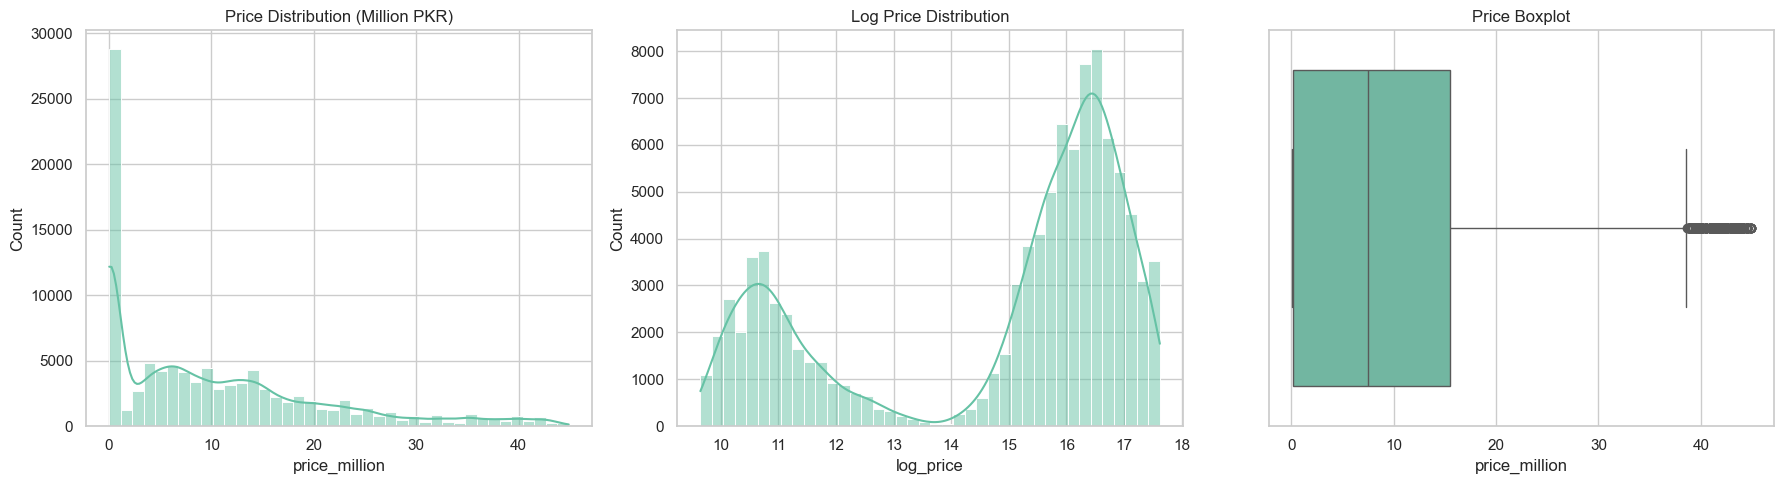

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["price_million"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Price Distribution (Million PKR)")

sns.histplot(df["log_price"], bins=40, kde=True, ax=axes[1])
axes[1].set_title("Log Price Distribution")

sns.boxplot(x=df["price_million"], ax=axes[2])
axes[2].set_title("Price Boxplot")

plt.tight_layout()
plt.show()

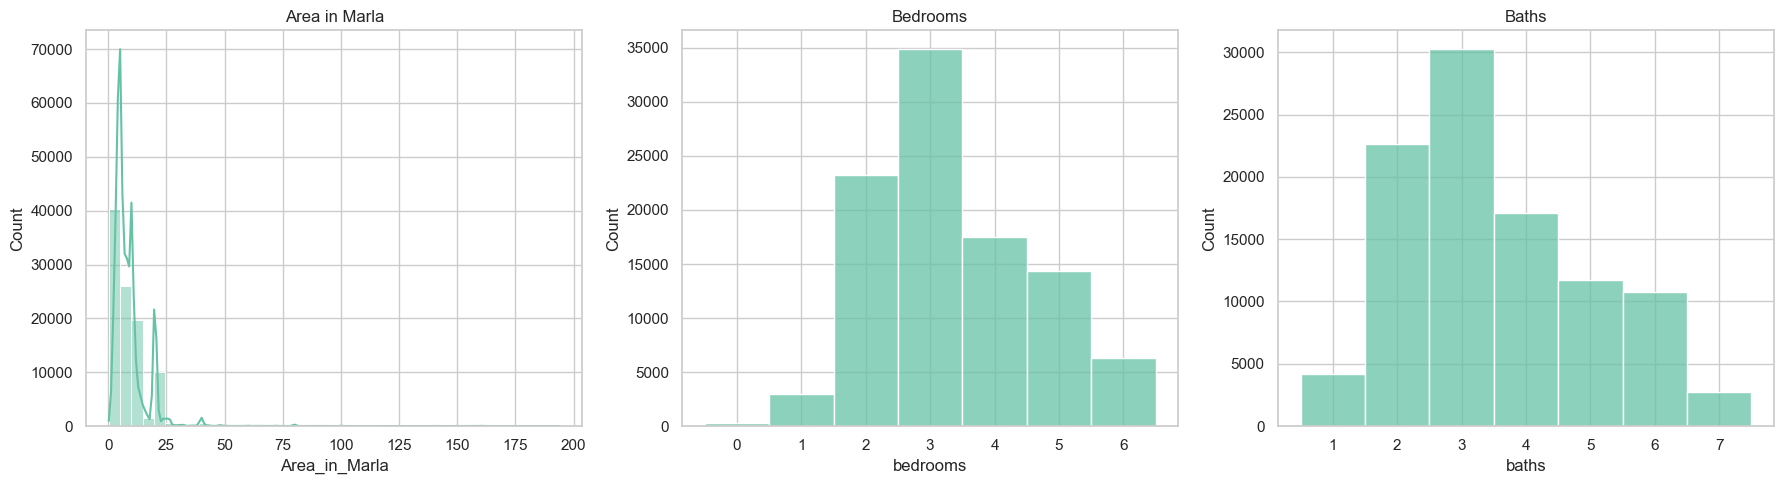

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Area_in_Marla"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Area in Marla")

sns.histplot(df["bedrooms"], discrete=True, ax=axes[1])
axes[1].set_title("Bedrooms")

sns.histplot(df["baths"], discrete=True, ax=axes[2])
axes[2].set_title("Baths")

plt.tight_layout()
plt.show()

## 5. Categorical EDA

This part shows how listings are distributed across cities, purposes, and property types.

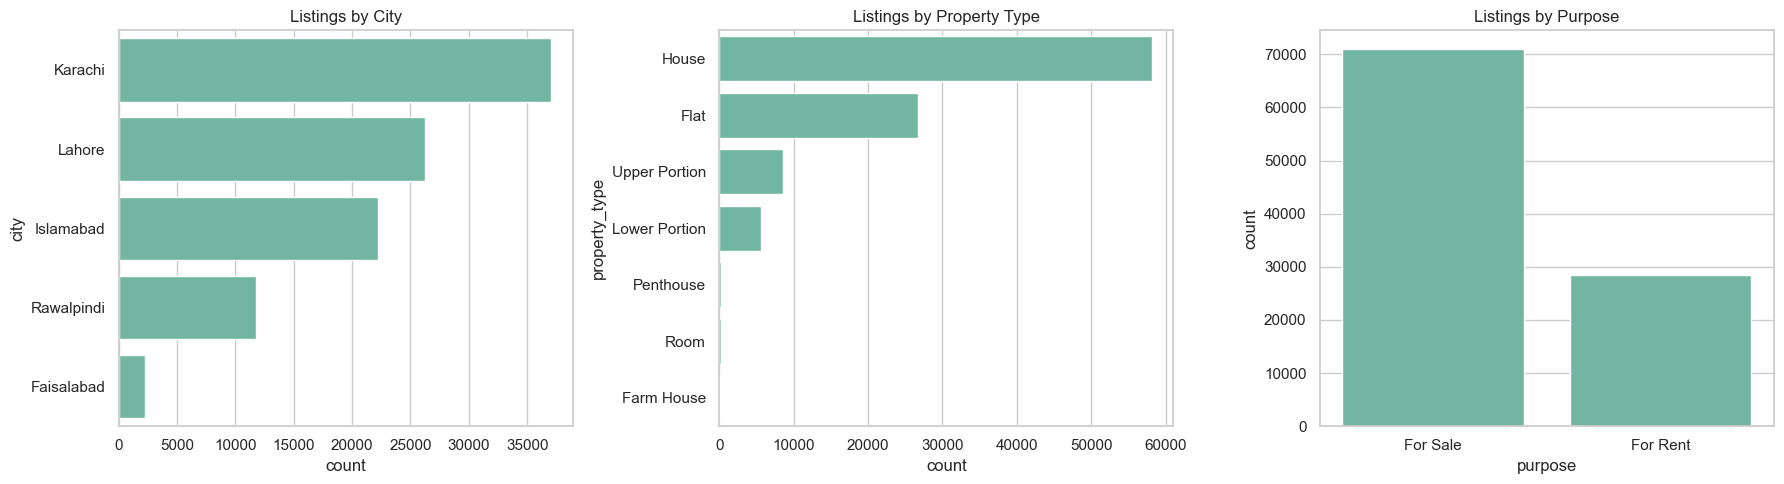

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, y="city", order=df["city"].value_counts().index, ax=axes[0])
axes[0].set_title("Listings by City")

sns.countplot(data=df, y="property_type", order=df["property_type"].value_counts().index, ax=axes[1])
axes[1].set_title("Listings by Property Type")

sns.countplot(data=df, x="purpose", order=df["purpose"].value_counts().index, ax=axes[2])
axes[2].set_title("Listings by Purpose")

plt.tight_layout()
plt.show()

In [10]:
city_summary = (
    df.groupby("city")
    .agg(
        listings=("city", "size"),
        median_price_million=("price_million", "median"),
        median_area=("Area_in_Marla", "median"),
        median_price_per_marla=("price_per_marla", "median"),
    )
    .sort_values("median_price_million", ascending=False)
    .round(2)
)

city_summary

,listings,median_price_million,median_area,median_price_per_marla
city,,,,
Lahore,26216,14.00,6.0,2033333.33
Karachi,37065,7.00,6.0,1416666.67
Faisalabad,2231,6.00,5.0,1400000.00
Rawalpindi,11737,4.80,7.0,1026315.79
Islamabad,22240,0.13,8.0,10289.92


## 6. Market insights by city and property type

Now we compare pricing patterns across different segments of the market.

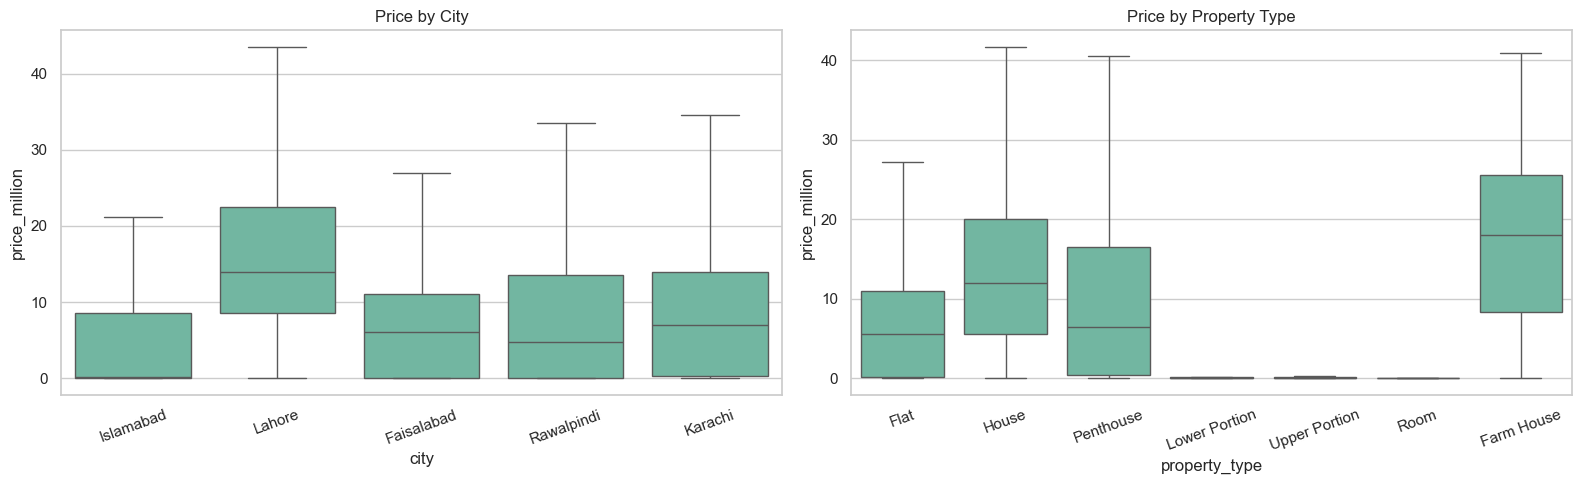

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x="city", y="price_million", ax=axes[0], showfliers=False)
axes[0].set_title("Price by City")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="property_type", y="price_million", ax=axes[1], showfliers=False)
axes[1].set_title("Price by Property Type")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

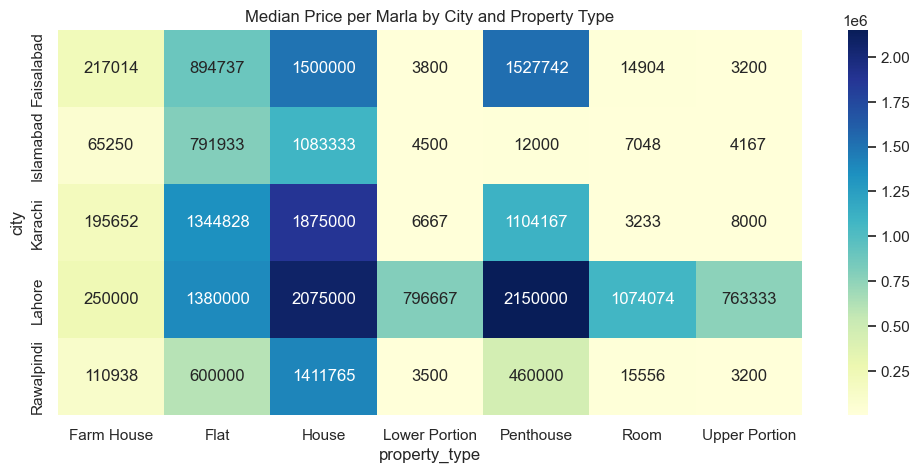

In [12]:
price_grid = (
    df.pivot_table(
        index="city",
        columns="property_type",
        values="price_per_marla",
        aggfunc="median",
    )
    .round(0)
)

plt.figure(figsize=(12, 5))
sns.heatmap(price_grid, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Median Price per Marla by City and Property Type")
plt.show()

In [13]:
city_location_stats = (
    df.groupby(["city", "location"])
    .agg(
        listings=("location", "size"),
        median_price_million=("price_million", "median"),
        median_price_per_marla=("price_per_marla", "median"),
    )
    .query("listings >= 20")
    .sort_values(["city", "median_price_per_marla"], ascending=[True, False])
    .reset_index()
)

city_location_stats.groupby("city").head(10)

,city,location,listings,median_price_million,median_price_per_marla
0,Faisalabad,Eden Valley,140,11.650,2.200000e+06
1,Faisalabad,Ghulam Mohammad Abad,25,7.500,2.000000e+06
2,Faisalabad,Four Season Housing,21,6.000,1.800000e+06
3,Faisalabad,Al Noor Garden,33,8.000,1.718750e+06
4,Faisalabad,Peoples Colony No 1,32,6.100,1.699057e+06
5,Faisalabad,Nisar Colony,25,7.500,1.660000e+06
6,Faisalabad,Peoples Colony No 2,35,10.000,1.603774e+06
7,Faisalabad,Mansoorabad,30,5.400,1.585714e+06
8,Faisalabad,Wapda City,77,12.000,1.550000e+06
9,Faisalabad,Sargodha Road,30,8.000,1.510000e+06


## 7. Relationships between numerical features

Area, bedrooms, baths, and price usually move together. These plots help us understand how strongly they relate.

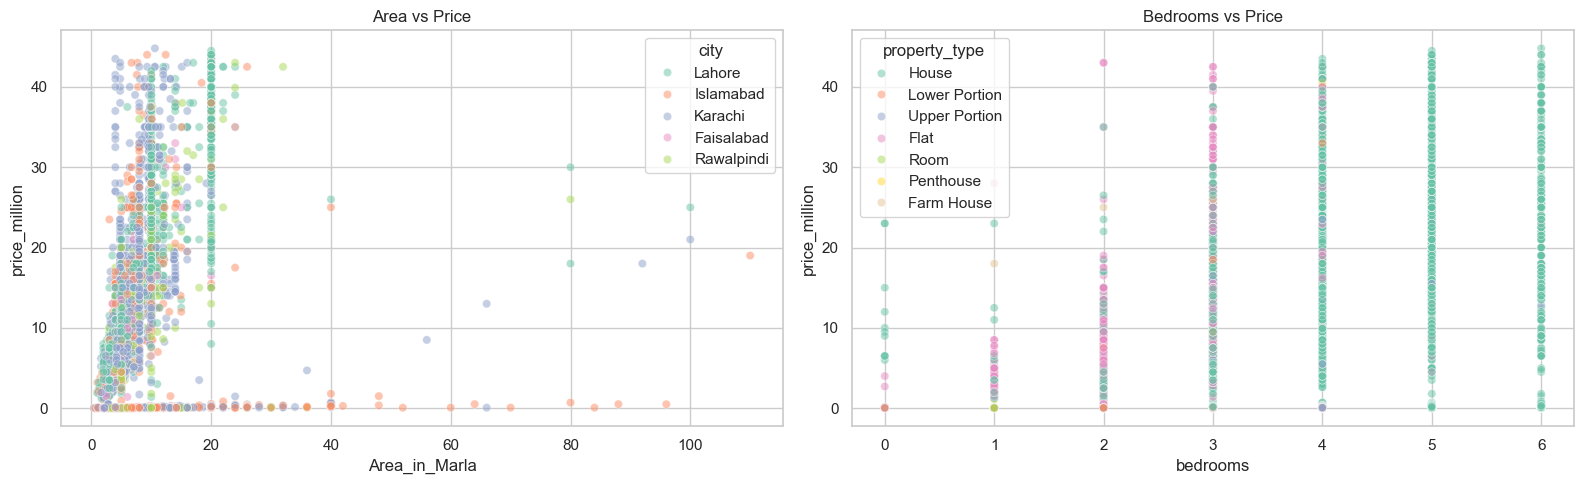

In [14]:
sample_df = df.sample(min(5000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.scatterplot(data=sample_df, x="Area_in_Marla", y="price_million", hue="city", alpha=0.5, ax=axes[0])
axes[0].set_title("Area vs Price")

sns.scatterplot(data=sample_df, x="bedrooms", y="price_million", hue="property_type", alpha=0.5, ax=axes[1])
axes[1].set_title("Bedrooms vs Price")

plt.tight_layout()
plt.show()

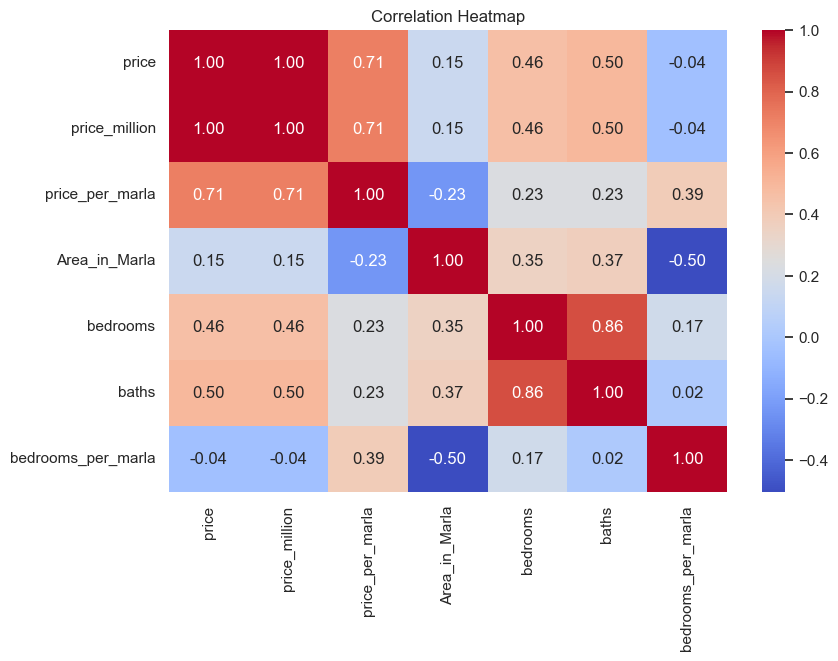

In [15]:
corr_cols = ["price", "price_million", "price_per_marla", "Area_in_Marla", "bedrooms", "baths", "bedrooms_per_marla"]
corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8. Outlier-focused analysis

Real estate data often has strong outliers. Instead of deleting them immediately, we inspect them first.

In [16]:
q1 = df["price_million"].quantile(0.25)
q3 = df["price_million"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

outlier_share = pd.Series({
    "q1": round(q1, 2),
    "q3": round(q3, 2),
    "upper_bound": round(upper_bound, 2),
    "high_price_outlier_rows": int((df["price_million"] > upper_bound).sum()),
    "high_price_outlier_pct": round((df["price_million"] > upper_bound).mean() * 100, 2),
})

outlier_share.to_frame("value")

,value
q1,0.15
q3,15.50
upper_bound,38.52
high_price_outlier_rows,2594.00
high_price_outlier_pct,2.61


In [17]:
premium_listings = (
    df.nlargest(15, "price_per_marla")
    [["city", "location", "property_type", "price_million", "Area_in_Marla", "price_per_marla", "bedrooms", "baths"]]
    .round(2)
)

premium_listings

,city,location,property_type,price_million,Area_in_Marla,price_per_marla,bedrooms,baths
75823,Lahore,Bahria Town,House,42.5,1.0,42500000.00,5,6
80336,Lahore,DHA Defence,House,41.0,1.0,41000000.00,5,6
98151,Lahore,DHA Defence,House,41.0,1.0,41000000.00,5,7
98446,Lahore,DHA Defence,House,41.0,1.0,41000000.00,5,6
77724,Lahore,DHA Defence,House,40.0,1.0,40000000.00,5,6
76726,Lahore,Bahria Town,House,39.0,1.0,39000000.00,5,7
78921,Lahore,Bahria Town,House,33.0,1.0,33000000.00,6,7
56112,Lahore,DHA Defence,House,26.0,1.0,26000000.00,4,5
78613,Lahore,DHA Defence,House,22.5,1.0,22500000.00,3,3
44705,Karachi,Gadap Town,Flat,3.2,0.2,16000000.00,2,2


## 9. Reusable city snapshot

This helper makes it easy to inspect any city in one line.

In [19]:
def city_snapshot(city_name):
    city_df = df[df["city"].eq(city_name)].copy()
    summary = {
        "listings": len(city_df),
        "median_price_million": city_df["price_million"].median(),
        "median_area": city_df["Area_in_Marla"].median(),
        "median_price_per_marla": city_df["price_per_marla"].median(),
        "median_bedrooms": city_df["bedrooms"].median(),
        "median_baths": city_df["baths"].median(),
    }
    return pd.Series(summary).round(2)


for city_name in sorted(df["city"].dropna().unique()):
    print(city_name)
    display(city_snapshot(city_name).to_frame("value"))

Faisalabad


,value
listings,2231.0
median_price_million,6.0
median_area,5.0
median_price_per_marla,1400000.0
median_bedrooms,3.0
median_baths,3.0


Islamabad


,value
listings,22240.00
median_price_million,0.13
median_area,8.00
median_price_per_marla,10289.92
median_bedrooms,3.00
median_baths,3.00


Karachi


,value
listings,37065.00
median_price_million,7.00
median_area,6.00
median_price_per_marla,1416666.67
median_bedrooms,3.00
median_baths,3.00


Lahore


,value
listings,26216.00
median_price_million,14.00
median_area,6.00
median_price_per_marla,2033333.33
median_bedrooms,4.00
median_baths,4.00


Rawalpindi


,value
listings,11737.00
median_price_million,4.80
median_area,7.00
median_price_per_marla,1026315.79
median_bedrooms,3.00
median_baths,3.00


## 10. Optional machine learning baseline

The notebook is mainly about analysis, but a quick model is useful for checking how predictive the available variables are.

In [20]:
model_df = df.dropna(subset=["price", "property_type", "location", "city", "purpose", "baths", "bedrooms", "Area_in_Marla"]).copy()

feature_cols = ["property_type", "location", "city", "purpose", "baths", "bedrooms", "Area_in_Marla", "price_per_marla"]
target_col = "log_price"

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["property_type", "location", "city", "purpose"]),
        ("num", SimpleImputer(strategy="median"), ["baths", "bedrooms", "Area_in_Marla", "price_per_marla"]),
    ]
)

model = Pipeline([
    ("prep", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1)),
])

model.fit(X_train, y_train)
pred = model.predict(X_test)

metrics = pd.Series({
    "MAE_on_log_price": mean_absolute_error(y_test, pred),
    "R2_on_log_price": r2_score(y_test, pred),
})

metrics.to_frame("score")

,score
MAE_on_log_price,0.002804
R2_on_log_price,0.999911


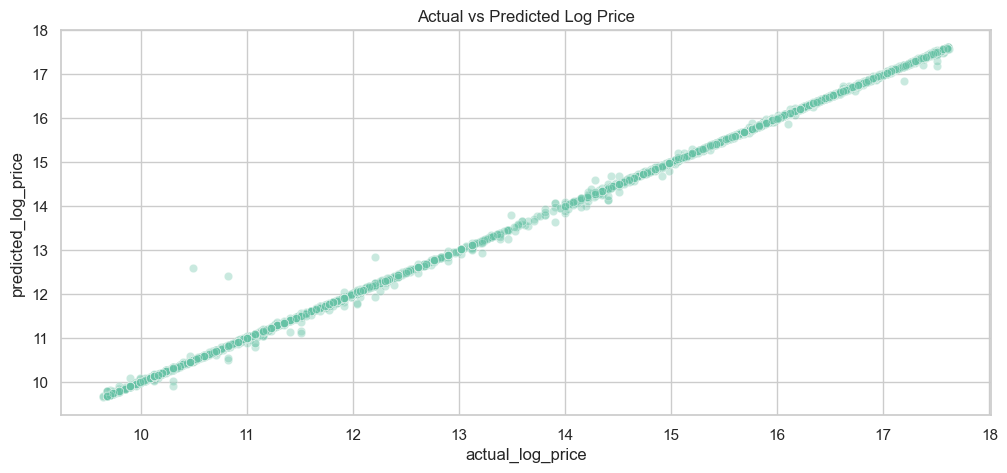

In [22]:
pred_df = pd.DataFrame({
    "actual_log_price": y_test,
    "predicted_log_price": pred,
})

fig, ax = plt.subplots()
sns.scatterplot(data=pred_df, x="actual_log_price", y="predicted_log_price", alpha=0.35, ax=ax)
ax.set_title("Actual vs Predicted Log Price")
plt.show()